In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
import pymannkendall as mk
from sklearn.linear_model import LinearRegression
import scipy.stats as stats
import tkinter as tk
from tkinter import filedialog
import math

In [3]:
root = tk.Tk()
root.withdraw()
file_path = filedialog.askopenfilename(title="Оберіть файл з даними", filetypes=[("CSV files", "*.csv"), ("Excel files", "*.xlsx"), ("TXT files", "*.txt")])

In [5]:
time_series = pd.read_csv(file_path, sep='\s+', header=None)
time_series

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,1.88,7.64,3.89,-2.9,-0.62,5.28,3.53,-2.08,-1.6,4.92,...,34.45,34.2,38.73,54.41,69.78,78.0,92.81,119.36,152.0,186.51


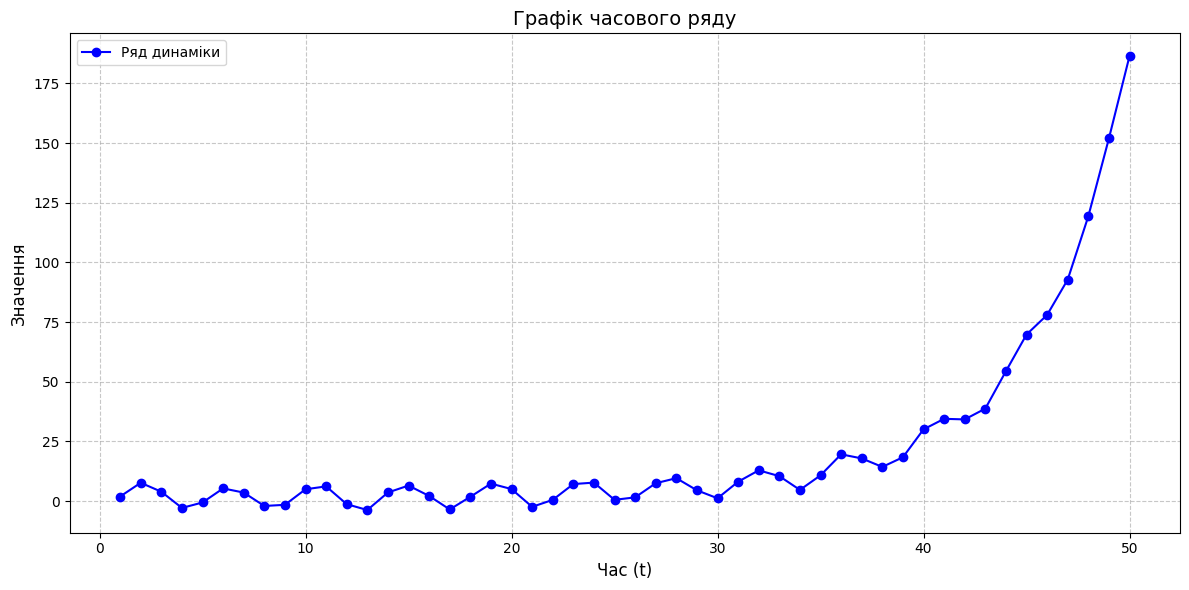

In [6]:
y = time_series.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(y) + 1), y, marker='o', linestyle='-', color='b', label='Ряд динаміки')

plt.title('Графік часового ряду', fontsize=14)
plt.xlabel('Час (t)', fontsize=12)
plt.ylabel('Значення', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
N = len(y)
C = 0
for i in range(N - 1):
    if y[i] < y[i + 1]:
        C += 1

M = (N - 1) / 2
D = (N + 1) / 12
K = (C - M) / math.sqrt(D)
print(f"C: {C}, M: {M}, D: {D}, K: {K}")

C: 31, M: 24.5, D: 4.25, K: 3.1529631254723287


In [8]:
alpha = 0.05
u_crit = stats.norm.ppf(1 - alpha / 2)

print(f"Статистика K = {K:.4f}")
print(f"Критичне значення u = {u_crit:.4f}")

if abs(K) <= u_crit:
    print("Висновок: |K| <= u — приймається гіпотеза H0 (ряд є випадковим).")
elif K < -u_crit:
    print("Висновок: K < -u — приймається гіпотеза H1 (наявний тренд з тенденцією до спадання).")
else:
    print("Висновок: K > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).")

Статистика K = 3.1530
Критичне значення u = 1.9600
Висновок: K > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).


In [13]:
h = np.zeros([N, N])

for i in range(N - 1):
    for j in range(i + 1, N):
        if y[i] < y[j]:
            h[i][j] = 1
        elif y[i] > y[j]:
            h[i][j] = 0
        else:
            h[i][j] = 0.5

T = np.sum(h)
M = N * (N - 1) / 2 * 0.5
D = (2 * N + 5) * N * (N - 1) / 72
U = (T - M + 0.5) / math.sqrt(D)

print(f"Статистика K = {U:.4f}")
print(f"Критичне значення u = {u_crit:.4f}")

if abs(U) <= u_crit:
    print("Висновок: |U| <= u — приймається гіпотеза H0 (ряд є випадковим).")
elif U < -u_crit:
    print("Висновок: U < -u — приймається гіпотеза H1 (наявний тренд з тенденцією до спадання).")
else:
    print("Висновок: U > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).")

Статистика K = 6.7923
Критичне значення u = 1.9600
Висновок: U > u — приймається гіпотеза H1 (наявний тренд з тенденцією до зростання).
